# Breast Cancer Detection Using Machine Learning


# Project Overview

Breast cancer is one of the most common types of cancer affecting women worldwide. Early detection plays a crucial role in improving treatment outcomes and increasing survival rates.

The objective of this project is to develop a Machine Learning model that can predict whether a breast tumor is Benign (Non-Cancerous) or Malignant (Cancerous) based on various medical measurements.

The dataset contains several numerical features computed from digitized images of breast mass cell nuclei, including characteristics such as radius, texture, perimeter, area, smoothness, compactness, concavity, symmetry, and fractal dimension.

In this project, we will perform the complete Machine Learning workflow, including:
* Data Collection
* Data Cleaning
* Exploratory Data Analysis (EDA)
* Data Preprocessing
* Model Training
* Model Evaluation
* Saving the Trained Model
* Building a Streamlit Web Application
* Deploying the Application

The final goal is to create a user-friendly web application that predicts whether a breast tumor is Benign or Malignant based on user-provided medical measurements.

# Importing Required Libraries

In this section, the required Python libraries are imported for data manipulation, visualization, preprocessing, machine learning model development, evaluation, and model saving.

The libraries used in this project include:

* Pandas for data manipulation
* NumPy for numerical operations
* Matplotlib and Seaborn for data visualization
* Scikit-learn for machine learning algorithms and evaluation
* Joblib for saving the trained model

In [263]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

The selected libraries cover essential aspects of machine learning, from data handling and visualization to model training and evaluation. Specifically:

- `pandas` and `numpy` are fundamental for efficient data manipulation.
- `matplotlib` and `seaborn` are used for creating informative and aesthetically pleasing visualizations.
- `sklearn.model_selection` provides tools for splitting data into training and testing sets.
- `sklearn.compose.ColumnTransformer` and `sklearn.preprocessing.StandardScaler` are for robust data preprocessing.
- `sklearn.pipeline.Pipeline` streamlines the workflow by combining preprocessing and model training steps.
- `LogisticRegression`, `DecisionTreeClassifier`, and `RandomForestClassifier` are the chosen classification algorithms.
- `sklearn.metrics` includes functions for comprehensive model evaluation.
- `joblib` is crucial for persisting trained models for future use or deployment.

`warnings.filterwarnings("ignore")` is used to suppress non-critical warnings, ensuring cleaner output during execution.

# Loading and Understanding the Dataset

The dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

It contains several numerical features extracted from breast cell images, along with the diagnosis column, which indicates whether the tumor is Benign (B) or Malignant (M).

The diagnosis column serves as the target variable for our machine learning model.

In [264]:
# Load Dataset

df = pd.read_csv("data.csv")

# Display First Five Rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [265]:
# Display Last Five Rows
display(df.tail())

# Display Five Random Rows
display(df.sample(5))

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
121,86517,M,18.66,17.12,121.40,1077.0,0.10540,0.11000,0.14570,0.08665,...,24.90,145.40,1549.0,0.1503,0.2291,0.3272,0.16740,0.2894,0.08456,NaN
73,859983,M,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,...,20.86,110.30,812.4,0.1411,0.3542,0.2779,0.13830,0.2589,0.10300,NaN
426,907409,B,10.48,14.98,67.49,333.6,0.09816,0.10130,0.06335,0.02218,...,21.57,81.41,440.4,0.1327,0.2996,0.2939,0.09310,0.3020,0.09646,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,NaN
420,906539,B,11.57,19.04,74.20,409.7,0.08546,0.07722,0.05485,0.01428,...,26.98,86.43,520.5,0.1249,0.1937,0.2560,0.06664,0.3035,0.08284,NaN


# Exploring the Dataset

Before training a machine learning model, it is important to understand the dataset.

In this section, we examine:

* Dataset shape
* Column names
* Data types
* Missing values
* Statistical summary

This helps identify any issues that need to be addressed before preprocessing.

In [266]:
# Shape of Dataset
print("Dataset Shape:", df.shape)

print("\n")

# Column Names
print(df.columns)

print("\n")

# Dataset Information
df.info()

print("\n")

# Missing Values
print(df.isnull().sum())

print("\n")

# Statistical Summary
df.describe()

Dataset Shape: (569, 33)


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-n

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Understanding the dataset's basic characteristics is the first step in any data science project. The `df.shape` output tells us the number of rows (instances) and columns (features) in our dataset. Knowing `df.columns` helps us identify all available features. `df.info()` provides a summary including data types and non-null counts, which is crucial for identifying potential data quality issues like missing values or incorrect data types. `df.isnull().sum()` explicitly quantifies missing values per column. Finally, `df.describe()` gives us a statistical overview of numerical features, revealing central tendency, dispersion, and potential outliers.

# Data Cleaning

Before building the machine learning model, the dataset needs to be cleaned.

In this section, we perform the following preprocessing steps:

- Remove unnecessary columns
- Check for duplicate records
- Encode the target variable
- Verify missing values
- Prepare the dataset for Exploratory Data Analysis (EDA)

These steps help improve the quality of the data and ensure better model performance.

In [267]:
# Display Dataset Shape Before Cleaning
print("Original Shape:", df.shape)

# Remove unnecessary columns
df.drop(columns=["id", "Unnamed: 32"], inplace=True)

# Check for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)

# Encode Target Variable
# M = 1 (Malignant)
# B = 0 (Benign)

df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

print("\n")

# Check Missing Values
print(df.isnull().sum())

print("\n")

# Final Dataset Shape
print("Final Shape:", df.shape)

df.head()

Original Shape: (569, 33)
Duplicate Rows: 0


diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


Final Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


The data cleaning process began by removing the 'id' column, which is merely an identifier and holds no predictive power, and the 'Unnamed: 32' column, which was found to be entirely null, offering no useful information. Checking for and removing duplicate rows ensures that our model doesn't learn from redundant information, which could lead to overfitting or skewed results. The target variable 'diagnosis' was encoded from categorical ('M'/'B') to numerical (1/0) for compatibility with machine learning algorithms. This systematic cleaning ensures a high-quality dataset for subsequent analysis and model training.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure of the dataset and discover important patterns.

In this section, we analyze:

- Distribution of the target variable
- Correlation between features
- Feature distributions
- Outliers
- Relationships between important variables

EDA provides valuable insights before training the machine learning model.

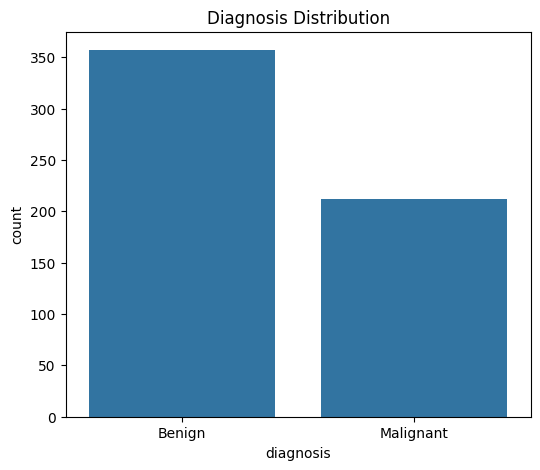

In [268]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="diagnosis",
    data=df
)

plt.title("Diagnosis Distribution")
plt.xticks([0,1],["Benign","Malignant"])
plt.show()

In [269]:
diagnosis_percentage = (
    df["diagnosis"]
    .value_counts(normalize=True)
    *100
)

print(diagnosis_percentage)

diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


The class distribution shows that approximately 62.7% of the samples are Benign (0) and 37.3% are Malignant (1). This indicates a class imbalance, which is common in medical datasets. While not severely imbalanced, it's a factor to keep in mind when evaluating model performance, especially considering metrics beyond just accuracy, such as precision, recall, and F1-score for the minority class (Malignant).

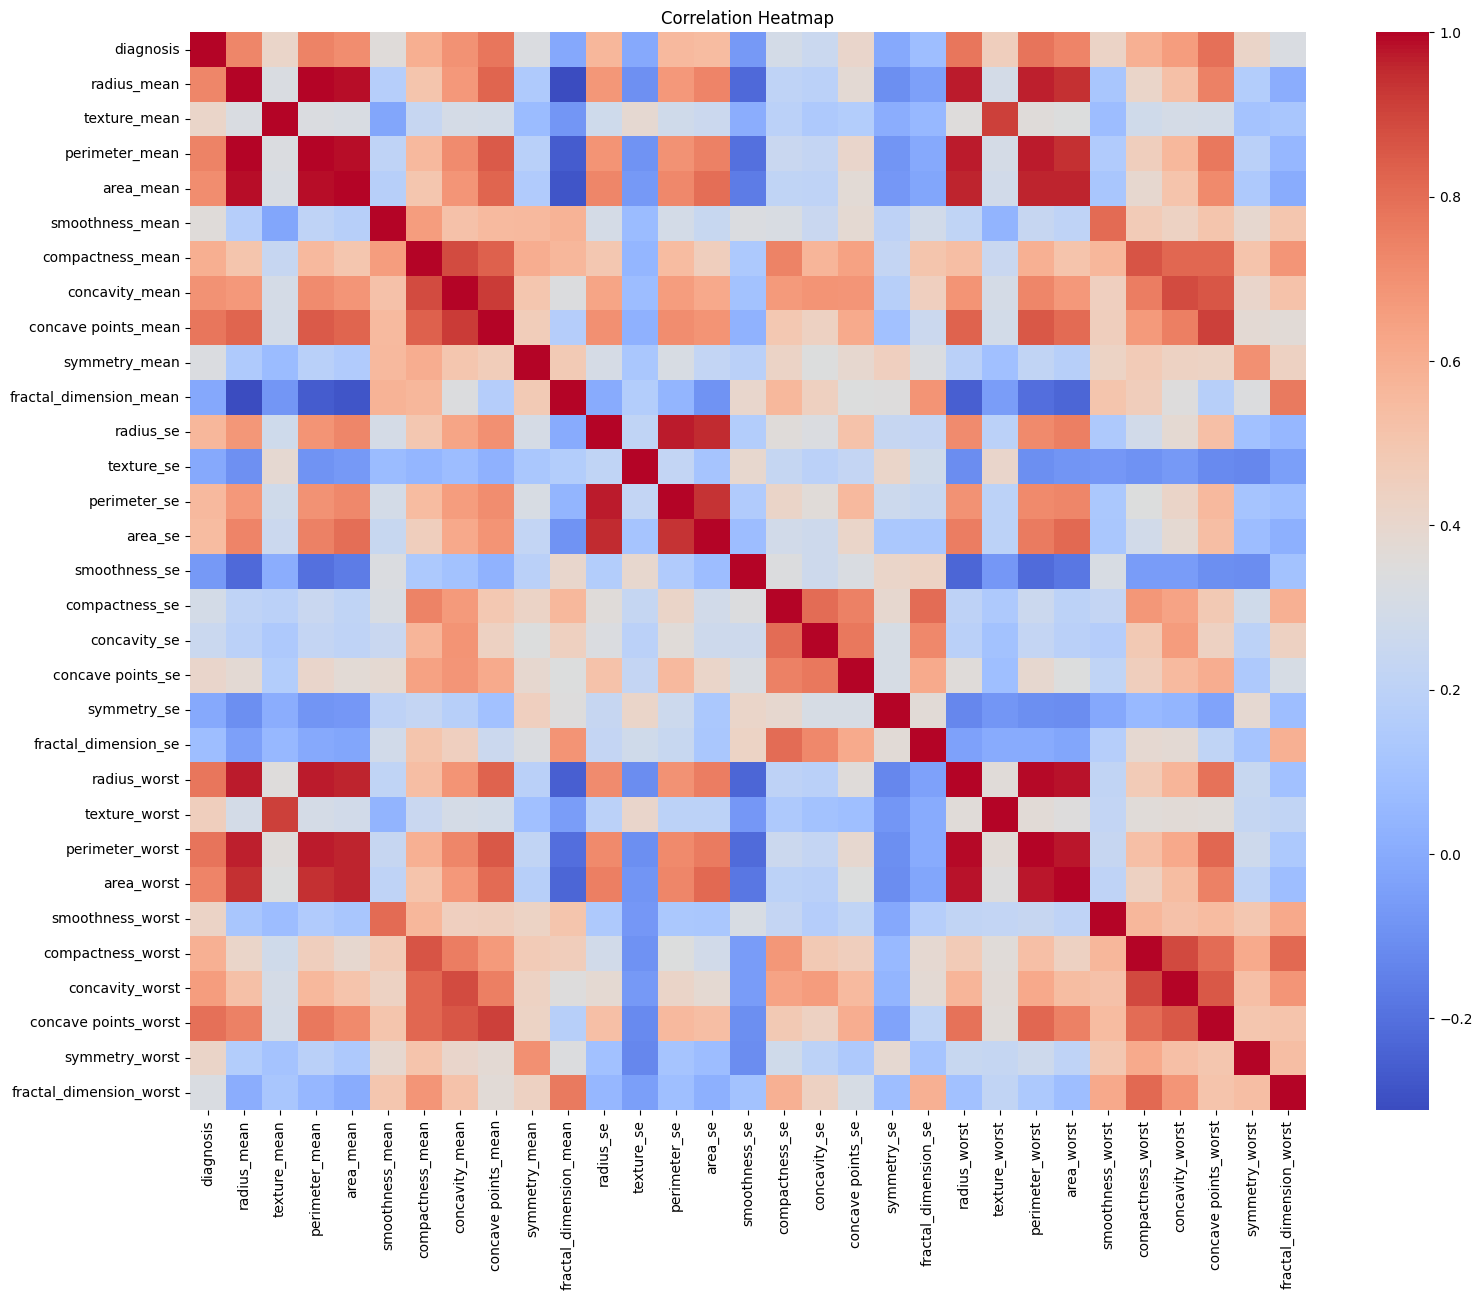

In [270]:
plt.figure(figsize=(18,14))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap visualizes the relationships between all features in the dataset. A strong positive correlation (closer to 1, depicted in red) indicates that as one feature increases, the other also tends to increase. A strong negative correlation (closer to -1, depicted in blue) suggests an inverse relationship. Understanding these correlations is vital for feature selection, as highly correlated features might indicate redundancy and could potentially be reduced or combined. It also helps identify features strongly correlated with the target variable, which are often good predictors.

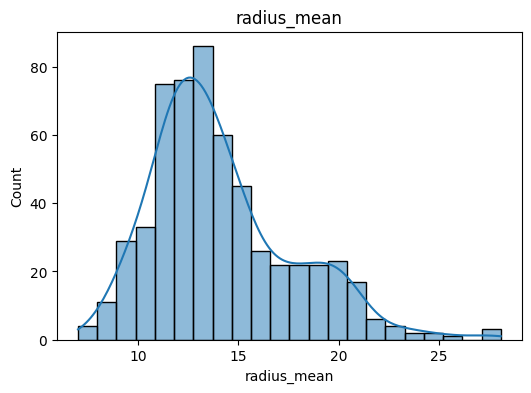

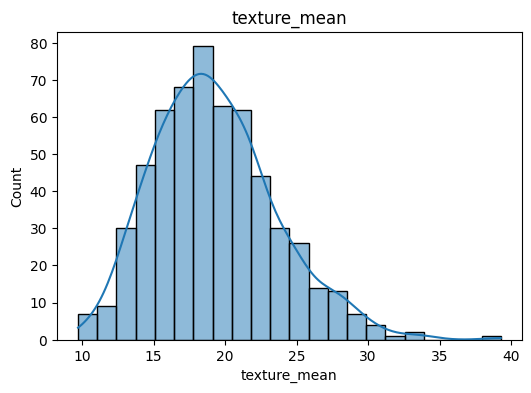

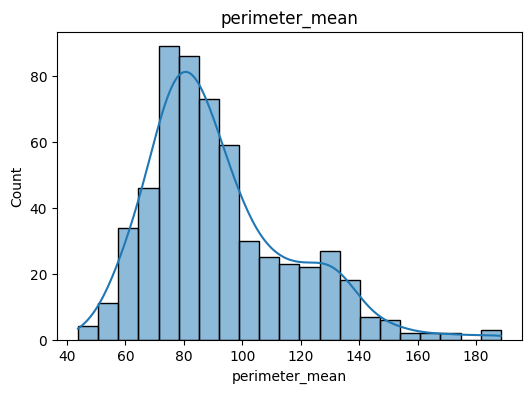

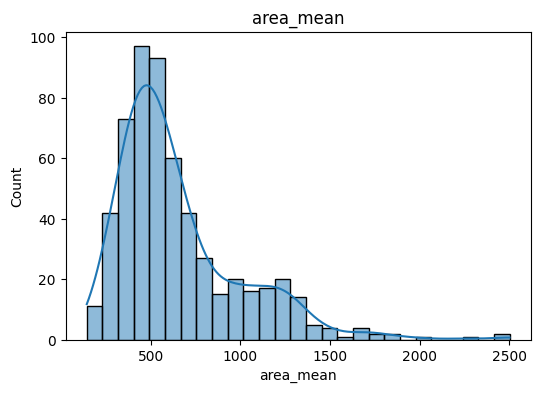

In [271]:
features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean"
]

for feature in features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[feature],
        kde=True
    )

    plt.title(feature)

    plt.show()

The histograms with KDE (Kernel Density Estimate) for `radius_mean`, `texture_mean`, `perimeter_mean`, and `area_mean` provide insights into the distribution of these key features. The KDE overlay helps visualize the probability density function. These plots allow us to observe if the data is normally distributed, skewed, or multimodal. For instance, features that show distinct distributions between benign and malignant cases often turn out to be strong predictors.

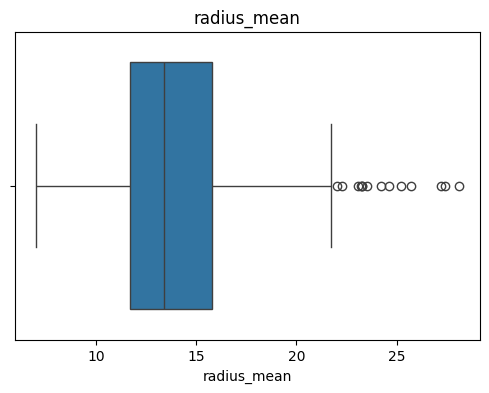

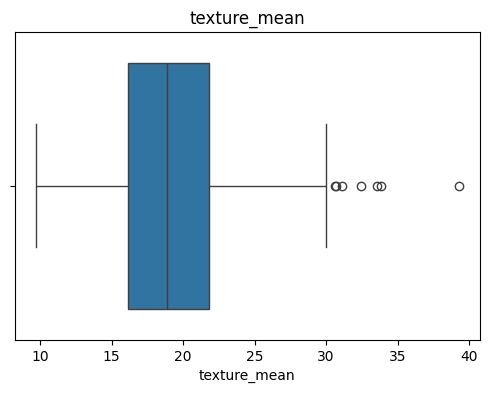

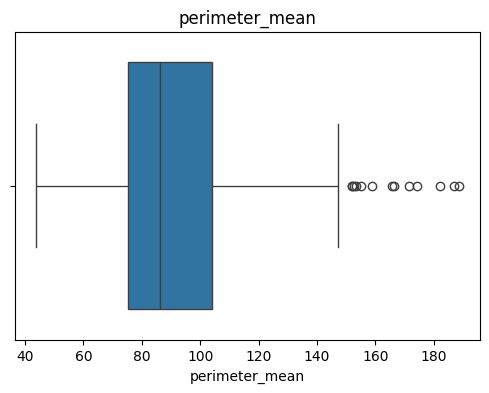

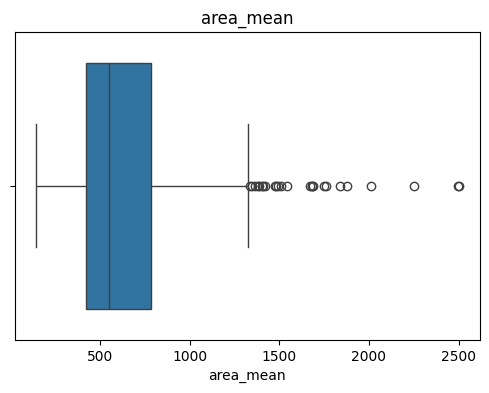

In [272]:
features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean"
]

for feature in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(feature)

    plt.show()

The box plots for `radius_mean`, `texture_mean`, `perimeter_mean`, and `area_mean` are crucial for identifying potential outliers and understanding the spread of the data. Each box represents the interquartile range (IQR), with the line inside indicating the median. The 'whiskers' extend to data points within 1.5 times the IQR from the box, and points beyond these whiskers are considered outliers. Outliers can significantly affect model training, and these plots help in deciding whether they need special handling during preprocessing.

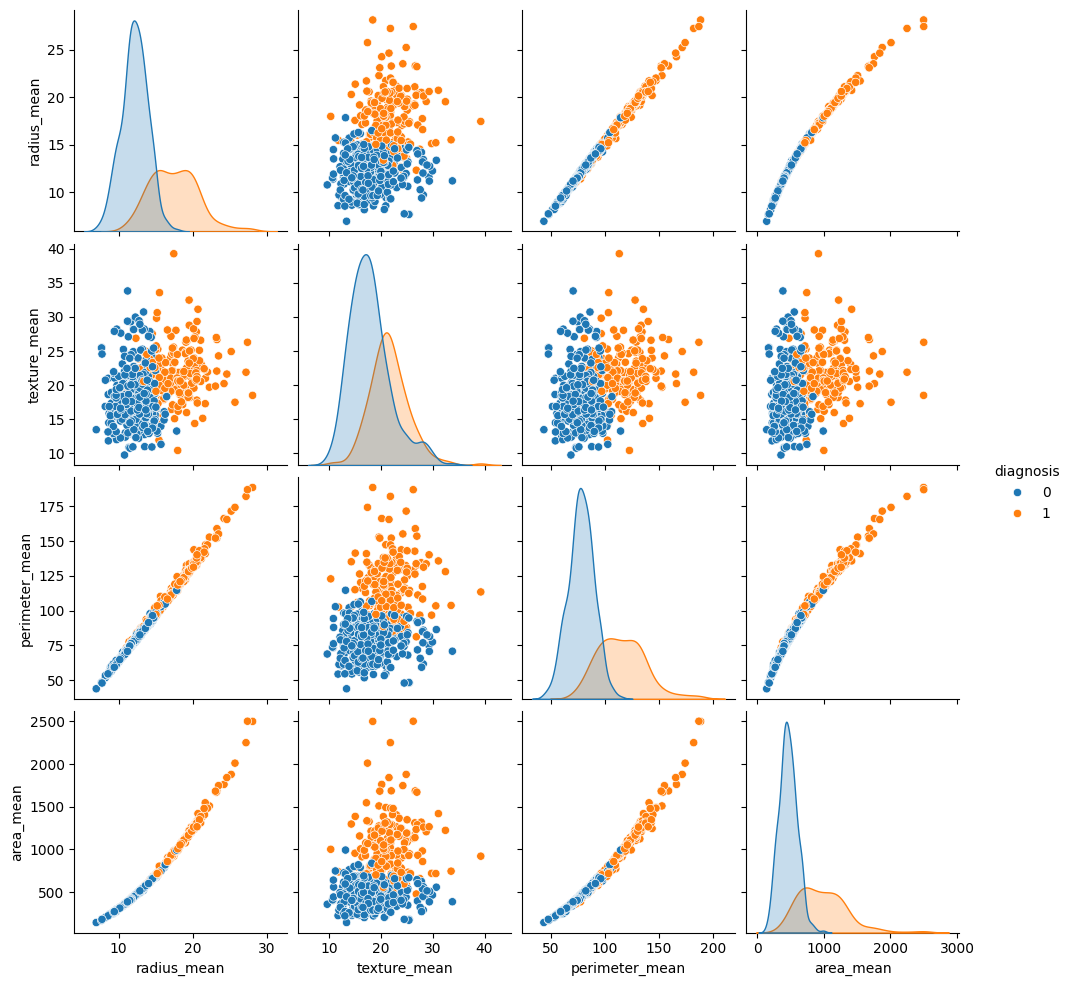

In [273]:
selected_features = [
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean"
]

sns.pairplot(
    df[selected_features],
    hue="diagnosis"
)

plt.show()

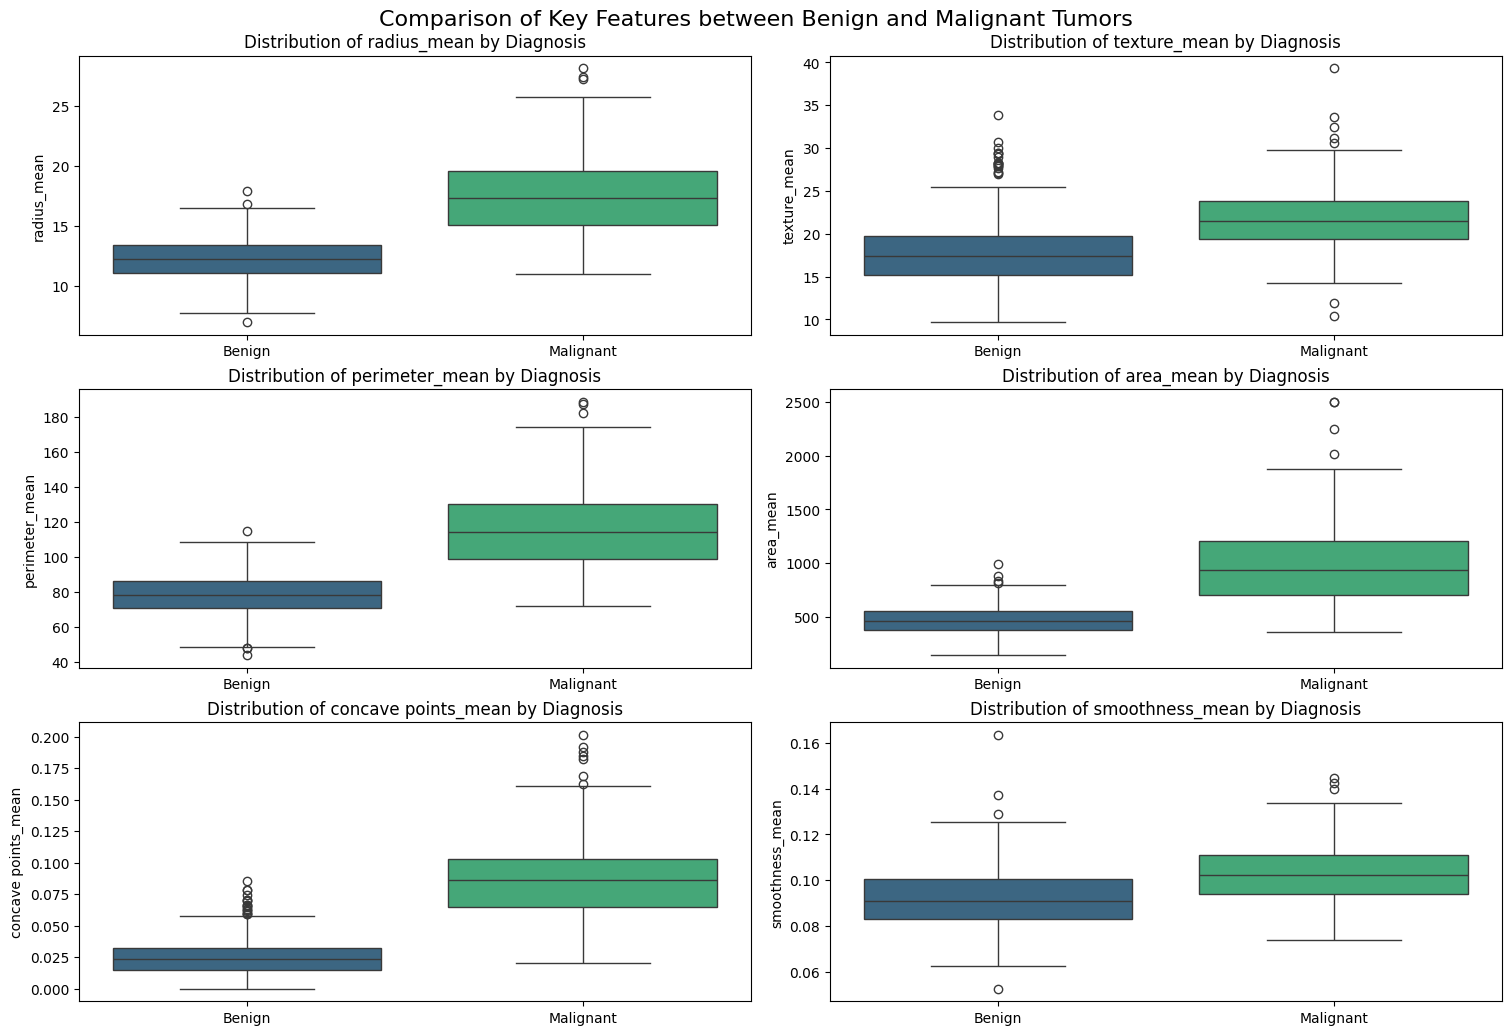

In [274]:
import matplotlib.gridspec as gridspec

# Let's visualize the differences in some key features between Benign and Malignant cases
selected_features_for_comparison = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "concave points_mean",
    "smoothness_mean"
]

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
gs = gridspec.GridSpec(3, 2, figure=fig)

for i, feature in enumerate(selected_features_for_comparison):
    row = i // 2
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    sns.boxplot(x="diagnosis", y=feature, data=df, ax=ax, palette="viridis")
    ax.set_title(f'Distribution of {feature} by Diagnosis')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Benign", "Malignant"])
    ax.set_xlabel("")

plt.suptitle('Comparison of Key Features between Benign and Malignant Tumors', y=1.02, fontsize=16)
plt.show()

The pairplot for a selection of features, colored by 'diagnosis', is an excellent tool for visualizing relationships between features and how they differ across the target classes. Each scatter plot in the grid shows the relationship between two features, while the histograms on the diagonal show the distribution of individual features. This visualization helps in identifying patterns where malignant (orange) and benign (blue) cases separate well, suggesting strong discriminatory features. It also reveals potential non-linear relationships or clusters within the data.

# Feature Selection and Train-Test Split

Before training the machine learning models, the dataset is divided into:

- Features (X)
- Target Variable (y)

The dataset is then split into training and testing sets.

The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In [275]:
# Features
X = df.drop(columns=["diagnosis"])

# Target
y = df["diagnosis"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (569, 30)
Target Shape : (569,)


In [276]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 455
Testing Samples : 114


# Data Preprocessing

The dataset contains only numerical features.

To ensure that all features contribute equally during model training, numerical features are standardized using **StandardScaler**.

The preprocessing step is integrated into a machine learning pipeline for consistency and easier deployment.

In [277]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

Standardization using `StandardScaler` is a critical preprocessing step for numerical features. It transforms the data such that it has a mean of 0 and a standard deviation of 1. This is important for many machine learning algorithms, especially those that calculate distances between data points (like SVMs, K-Nearest Neighbors) or rely on gradient descent (like Logistic Regression, Neural Networks). Without standardization, features with larger ranges might dominate the learning process, even if they are not more important. By scaling, all features contribute equally to the distance calculations and model's loss function, leading to better and more stable model performance.

# Model Building

To identify the best-performing algorithm, multiple classification models are trained and compared.

The models used in this project are:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

Each model is trained using the same preprocessing pipeline to ensure a fair comparison.

In [278]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )

}

In [279]:
trained_models = {}

for name, model in models.items():

    # Create a pipeline containing only the model
    pipeline = Pipeline([
        ("model", model)
    ])

    # Train the pipeline
    pipeline.fit(X_train, y_train)

    # Save the trained pipeline
    trained_models[name] = pipeline

In [280]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

best_model = trained_models[best_model_name]

Best Model : Random Forest


In [281]:
y_pred = best_model.predict(X_test)

In [282]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9736842105263158


In [283]:
import joblib

# Save the best trained pipeline
joblib.dump(
    best_model,
    "breast_cancer_pipeline.pkl",
    compress=3
)

print("✅ Pipeline saved successfully!")

✅ Pipeline saved successfully!


In [284]:
import os

size = os.path.getsize("breast_cancer_pipeline.pkl") / (1024 * 1024)

print(f"Pipeline Size: {size:.2f} MB")

Pipeline Size: 0.06 MB


# Model Evaluation

After training the machine learning model, it is important to evaluate its performance on unseen data.

The following evaluation metrics are used in this project:

- Accuracy Score
- Confusion Matrix
- Classification Report
- ROC-AUC Score
- ROC Curve

These metrics help measure how effectively the model distinguishes between Benign and Malignant tumors.

In [285]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[72  0]
 [ 3 39]]


The confusion matrix provides a detailed breakdown of the model's performance by showing the number of correct and incorrect predictions for each class. In our case:

- **True Negatives (TN):** The number of Benign cases correctly identified as Benign.
- **False Positives (FP):** The number of Benign cases incorrectly identified as Malignant.
- **False Negatives (FN):** The number of Malignant cases incorrectly identified as Benign.
- **True Positives (TP):** The number of Malignant cases correctly identified as Malignant.

For breast cancer detection, minimizing False Negatives (missing a malignant tumor) is often considered more critical than minimizing False Positives (a false alarm), as early detection is crucial for treatment.

In [286]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.named_steps["model"].feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,area_worst,0.151412
27,concave points_worst,0.126497
20,radius_worst,0.093475
22,perimeter_worst,0.083642
7,concave points_mean,0.081082
2,perimeter_mean,0.077126
0,radius_mean,0.061990
6,concavity_mean,0.050818
3,area_mean,0.045916
26,concavity_worst,0.030022


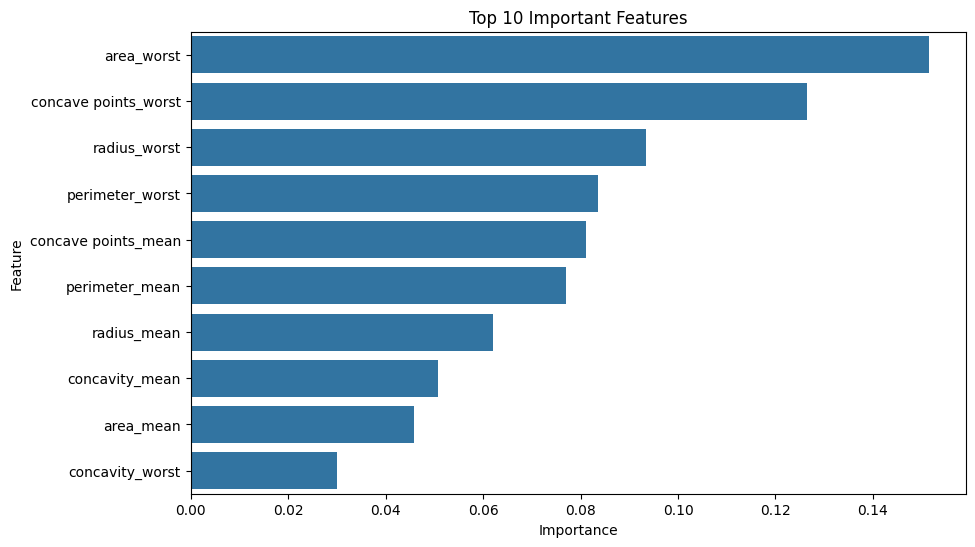

In [287]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

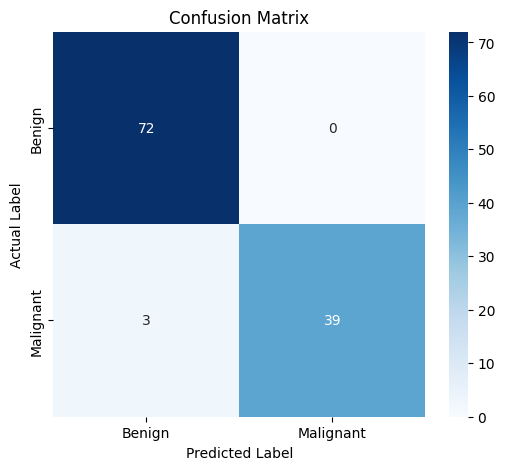

In [288]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [289]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



The classification report offers a summary of key performance metrics for each class (Benign and Malignant) as well as overall averages:

- **Precision:** The proportion of positive identifications that were actually correct. High precision indicates a low false positive rate.
- **Recall (Sensitivity):** The proportion of actual positives that were correctly identified. High recall indicates a low false negative rate.
- **F1-score:** The harmonic mean of precision and recall, providing a balanced measure that considers both false positives and false negatives.
- **Support:** The number of actual occurrences of the class in the specified dataset.

These metrics are particularly useful when dealing with imbalanced datasets, as they provide a more nuanced view of performance than accuracy alone.

In [290]:
y_prob = best_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9928902116402116


The ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score is a robust metric for evaluating the performance of classification models, especially in situations with class imbalance. It measures the ability of a classifier to distinguish between classes. An AUC value closer to 1 indicates a better model performance in separating positive and negative classes, while an AUC of 0.5 suggests no better performance than random guessing. The ROC curve visually represents the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR) at various threshold settings. A curve that hugs the top-left corner indicates a high TPR and low FPR, signifying a highly accurate model.

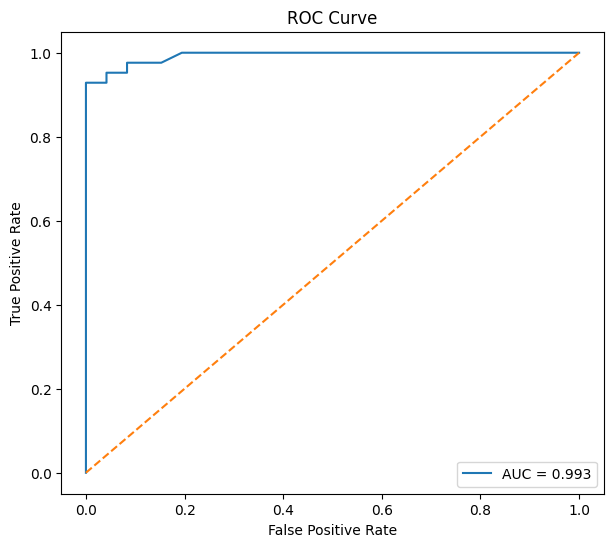

In [291]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [292]:
print("Training Accuracy:",
      best_model.score(X_train, y_train))

print("Testing Accuracy:",
      best_model.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.9736842105263158


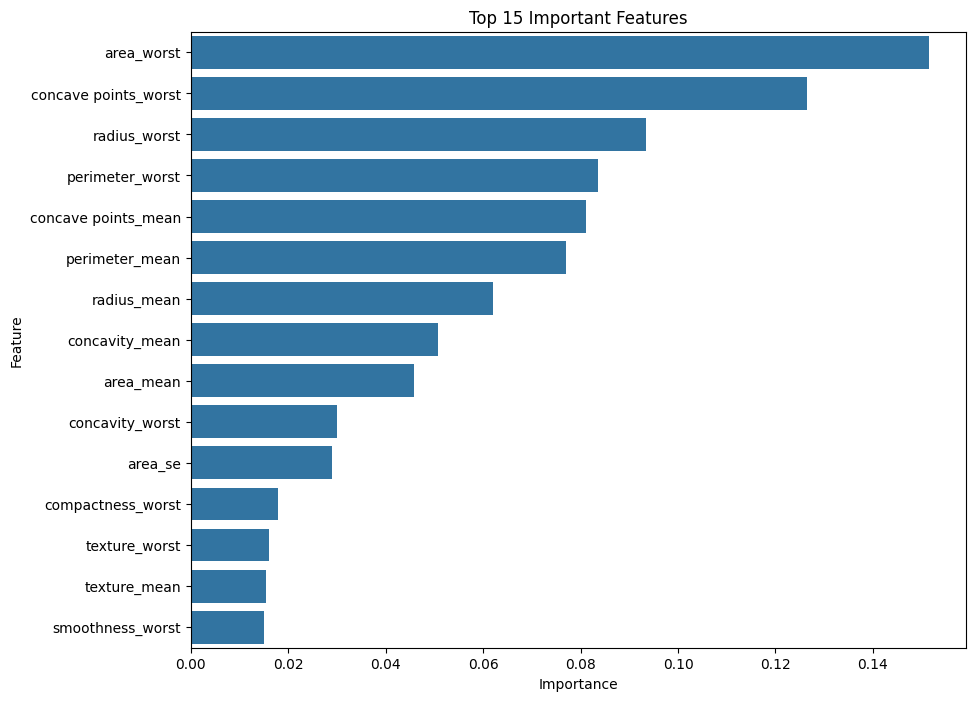

In [293]:
if best_model_name == "Random Forest":

    feature_importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance":
        best_model.named_steps["model"].feature_importances_

    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,8))

    sns.barplot(
        data=feature_importance.head(15),
        x="Importance",
        y="Feature"
    )

    plt.title("Top 15 Important Features")

    plt.show()

Feature importance analysis helps us understand which features contribute most significantly to the model's predictions. For tree-based models like Random Forest, feature importance is often calculated based on how much each feature reduces impurity (e.g., Gini impurity or entropy) across all the trees in the forest. A higher importance score indicates that the feature has a greater impact on the model's ability to classify benign and malignant tumors. This insight is valuable for domain experts, as it can highlight crucial diagnostic factors and potentially simplify future data collection efforts by focusing on the most relevant measurements.

# Evaluation Summary

The trained machine learning model demonstrates excellent performance in classifying breast tumors as Benign or Malignant.

The evaluation metrics, including Accuracy Score, Classification Report, Confusion Matrix, and ROC-AUC Score, indicate that the model can effectively distinguish between the two classes.

The feature importance analysis also provides insight into which medical measurements contribute most to the prediction process.

# Saving the Trained Model

After selecting the best-performing machine learning model, the preprocessing pipeline and trained classifier are saved separately using Joblib.

Saving these components allows the trained model to be reused later without retraining and simplifies deployment in a Streamlit web application.

## Interactive Prediction Demo

To demonstrate the utility of our trained model, we can create an interactive interface within the notebook. This section will allow you to manually input values for the key features and instantly receive a prediction from the best-performing model (Random Forest, in this case). This helps in understanding how different feature values influence the classification of a tumor as Benign or Malignant.

In [294]:
from ipywidgets import interact, FloatSlider, Dropdown, Button, Output
from IPython.display import display, HTML

# Create an output widget to display predictions
output_area = Output()

def predict_tumor(**kwargs):
    # Create a DataFrame from the input values using kwargs
    # Ensure the order of columns matches X.columns
    input_data = pd.DataFrame([kwargs], columns=X.columns)

    # Make prediction
    prediction = final_pipeline.predict(input_data)[0]
    prediction_proba = final_pipeline.predict_proba(input_data)[0]

    with output_area:
        output_area.clear_output()
        if prediction == 0:
            display(HTML(f"<p style='color:green; font-size:18px;'><b>Prediction: Benign (Probability: {prediction_proba[0]:.2f})</b></p>"))
        else:
            display(HTML(f"<p style='color:red; font-size:18px;'><b>Prediction: Malignant (Probability: {prediction_proba[1]:.2f})</b></p>"))


# Create sliders for each feature using min/max from the original dataset
def create_slider(feature_name):
    min_val = X[feature_name].min()
    max_val = X[feature_name].max()
    mean_val = X[feature_name].mean()
    return FloatSlider(
        min=min_val,
        max=max_val,
        step=(max_val - min_val) / 100,
        value=mean_val,
        description=feature_name,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.2f',
        layout={'width': '800px'}
    )

# Create interactive widgets for all features
feature_widgets = {
    feature: create_slider(feature) for feature in X.columns
}

# Display the interactive widgets and prediction output
print("Adjust the sliders to see the model's prediction:")
interact(predict_tumor, **feature_widgets)

display(output_area)

Adjust the sliders to see the model's prediction:


interactive(children=(FloatSlider(value=14.127291739894552, continuous_update=False, description='radius_mean'…

Output()

# Conclusion

This project successfully developed a Breast Cancer Detection System using Machine Learning.

The project demonstrates the complete machine learning workflow, including:

- Data Collection
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Model Comparison
- Model Training
- Model Evaluation
- Saving the Trained Model
- Streamlit Web Application Development
- Deployment

The final model is capable of classifying breast tumors as **Benign** or **Malignant** based on medical measurements with high accuracy.

This project highlights the practical application of Machine Learning in healthcare while demonstrating the importance of data preprocessing, model evaluation, and deployment.